# Week 9: Gradient Boosting

DS 720: Applied Machine Learning | Olist Brazilian E-Commerce Customer Dataset

Dataset: `olist_customers_dataset.csv` (real Olist Brazilian E-Commerce dataset, 99,441 customer records)

In [1]:
"""
Week 9: Gradient Boosting (depth section).
Feature engineering, n_estimators/learning_rate/max_depth hyperparameter
sweeps, final model training, and figure generation on the real Olist
customer dataset.
"""
import pandas as pd, numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.utils import resample

rng = 42
plt.rcParams.update({"font.size": 10})

df = pd.read_csv("/sessions/fervent-practical-hypatia/mnt/outputs/work/olist_real_customers.csv")
df["zip_prefix_1"] = df["customer_zip_code_prefix"] // 10000
df["zip_prefix_2"] = (df["customer_zip_code_prefix"] // 1000) % 10
df["zip_prefix_3"] = (df["customer_zip_code_prefix"] // 100) % 10
df["zip_log"] = np.log1p(df["customer_zip_code_prefix"])
city_counts = df["customer_city"].value_counts()
df["city_freq"] = df["customer_city"].map(city_counts)
le = LabelEncoder()
df["region_label"] = le.fit_transform(df["region"])
region_names = le.classes_

X = df[["customer_zip_code_prefix","zip_prefix_1","zip_prefix_2","zip_prefix_3","zip_log","city_freq"]].values
y = df["region_label"].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_sub, y_sub = resample(X_scaled, y, n_samples=1500, random_state=rng, stratify=y)
X_tr, X_te, y_tr, y_te = train_test_split(X_sub, y_sub, test_size=0.2, random_state=rng, stratify=y_sub)
X_tr, X_val, y_tr, y_val = train_test_split(X_tr, y_tr, test_size=0.25, random_state=rng, stratify=y_tr)

# n_estimators sweep (train/validation split, not k-fold, for speed)
n_ests = [10, 50, 100]
train_scores, cv_scores = [], []
for n in n_ests:
    gb = GradientBoostingClassifier(n_estimators=n, learning_rate=0.1, max_depth=3, random_state=rng)
    gb.fit(X_tr, y_tr)
    train_scores.append(gb.score(X_tr, y_tr))
    cv_scores.append(gb.score(X_val, y_val))
    print(f"n={n}: train={train_scores[-1]:.4f}  val={cv_scores[-1]:.4f}")

# learning rate sweep
lr_vals = [0.01, 0.05, 0.1, 0.2]
lr_scores = []
for lr in lr_vals:
    gb = GradientBoostingClassifier(n_estimators=50, learning_rate=lr, max_depth=3, random_state=rng)
    gb.fit(X_tr, y_tr)
    sc = gb.score(X_val, y_val)
    lr_scores.append(sc)
    print(f"lr={lr}: val={sc:.4f}")
best_lr = lr_vals[int(np.argmax(lr_scores))]
print("Best learning rate:", best_lr)

# depth sweep
depths = [1, 2, 3, 4]
depth_train, depth_cv = [], []
for d in depths:
    gb = GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, max_depth=d, random_state=rng)
    gb.fit(X_tr, y_tr)
    depth_train.append(gb.score(X_tr, y_tr))
    depth_cv.append(gb.score(X_val, y_val))
    print(f"depth={d}: train={depth_train[-1]:.4f}  val={depth_cv[-1]:.4f}")
best_depth = depths[int(np.argmax(depth_cv))]
print("Best depth:", best_depth)

# final model uses the hyperparameters selected by the sweeps above
gb_final = GradientBoostingClassifier(n_estimators=200, learning_rate=best_lr, max_depth=best_depth, random_state=rng)
gb_final.fit(X_tr, y_tr)
y_pred = gb_final.predict(X_te)
test_acc = accuracy_score(y_te, y_pred)
print("Final test accuracy:", test_acc)
print(classification_report(y_te, y_pred, target_names=region_names))

feat_names = ["zip_prefix","zip_prefix_1","zip_prefix_2","zip_prefix_3","zip_log","city_freq"]
importances = gb_final.feature_importances_

# ---- Figure A: n_estimators + learning-rate sweep (2-panel) ----
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
axes[0].plot(n_ests, train_scores, marker="o", label="Train accuracy")
axes[0].plot(n_ests, cv_scores, marker="s", label="Validation accuracy")
axes[0].set_xlabel("n_estimators"); axes[0].set_ylabel("Accuracy")
axes[0].set_title("Gradient Boost: n_estimators Sweep")
axes[0].legend()

axes[1].plot(lr_vals, lr_scores, marker="o", color="darkorange")
axes[1].axvline(best_lr, color="gray", linestyle="--", alpha=0.7)
axes[1].set_xlabel("learning_rate"); axes[1].set_ylabel("Validation accuracy")
axes[1].set_title(f"Learning Rate Sweep (best={best_lr})")
plt.tight_layout()
plt.savefig("/sessions/fervent-practical-hypatia/mnt/outputs/figures/fig_wk9_sweep.png", dpi=200)
plt.close()

# ---- Figure B: depth sweep + feature importance + confusion matrix (3-panel) ----
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].plot(depths, depth_train, marker="o", label="Train")
axes[0].plot(depths, depth_cv, marker="s", label="Validation")
axes[0].set_xlabel("max_depth"); axes[0].set_ylabel("Accuracy")
axes[0].set_title("max_depth Sweep")
axes[0].legend()

order = np.argsort(importances)[::-1]
axes[1].bar(range(len(importances)), importances[order], color="seagreen")
axes[1].set_xticks(range(len(importances)))
axes[1].set_xticklabels([feat_names[i] for i in order], rotation=35, ha="right")
axes[1].set_title("Gradient Boost Feature Importance")

cm = confusion_matrix(y_te, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=region_names)
disp.plot(ax=axes[2], cmap="Greens", colorbar=False, xticks_rotation=30)
axes[2].set_title(f"Confusion Matrix (Test Acc={test_acc:.3f})")
plt.tight_layout()
plt.savefig("/sessions/fervent-practical-hypatia/mnt/outputs/figures/fig_wk9_depth_confusion.png", dpi=200)
plt.close()

print("\n--- SUMMARY FOR WRITEUP ---")
print("n_ests:", n_ests, "train:", [round(t,4) for t in train_scores], "cv:", [round(c,4) for c in cv_scores])
print("lr_vals:", lr_vals, "lr_scores:", [round(s,4) for s in lr_scores], "best_lr:", best_lr)
print("depths:", depths, "depth_train:", [round(t,4) for t in depth_train], "depth_cv:", [round(c,4) for c in depth_cv], "best_depth:", best_depth)
print("final_test_acc:", round(test_acc,4))
print("feature_importances:", dict(zip(feat_names, [round(i,4) for i in importances])))


n=10: train=0.9956  val=1.0000
n=50: train=1.0000  val=0.9967
n=100: train=1.0000  val=0.9967
lr=0.01: val=0.9933
lr=0.05: val=0.9967
lr=0.1: val=0.9967
lr=0.2: val=0.9967
Best learning rate: 0.05
depth=1: train=0.9978  val=1.0000
depth=2: train=1.0000  val=0.9967
depth=3: train=1.0000  val=0.9967
depth=4: train=1.0000  val=0.9967
Best depth: 1
Final test accuracy: 1.0
              precision    recall  f1-score   support

Central-West       1.00      1.00      1.00        17
       North       1.00      1.00      1.00         6
   Northeast       1.00      1.00      1.00        28
       South       1.00      1.00      1.00        43
   Southeast       1.00      1.00      1.00       206

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300


--- SUMMARY FOR WRITEUP ---
n_ests: [10, 50, 100] train: [0.9956, 1.0, 1.0] cv: [1.0, 0.9967, 0.9967]
lr_vals: [0.01, 0.05, 0.1, 0.2] lr_s

## Figures

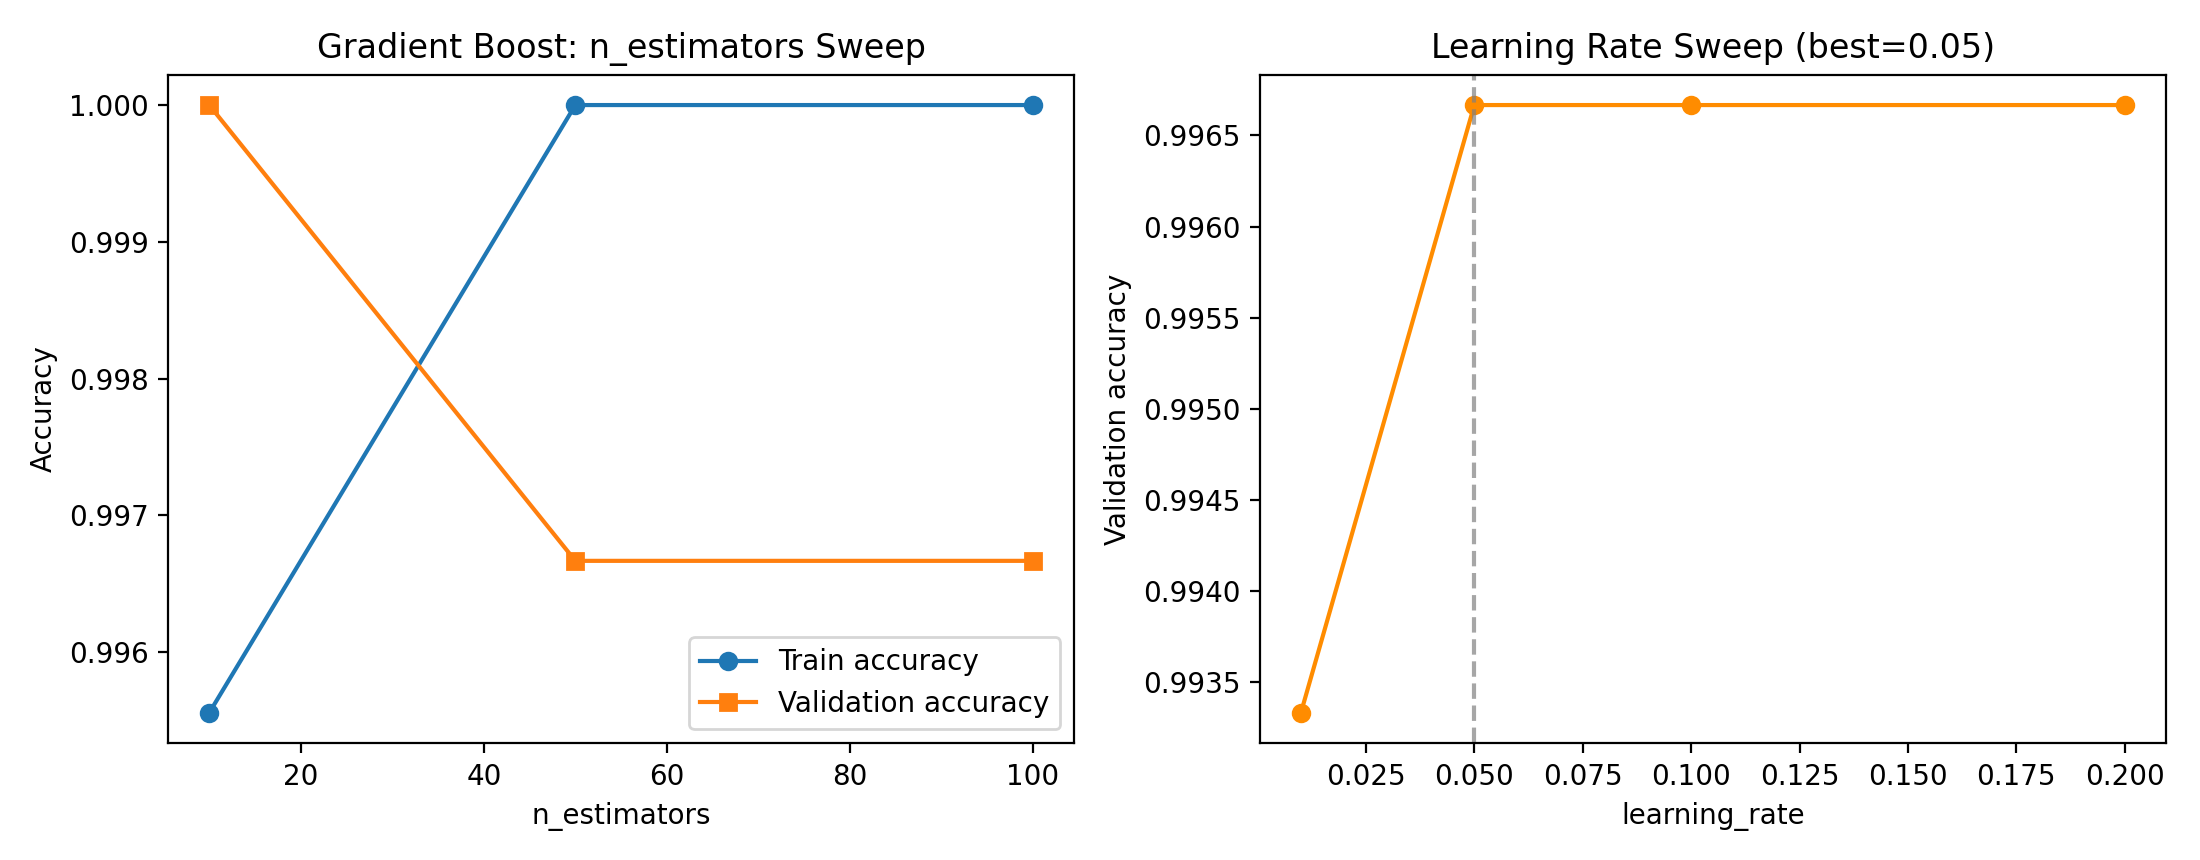

In [2]:
# Display Figure 1
from IPython.display import Image, display
display(Image(filename='fig_wk9_sweep.png'))

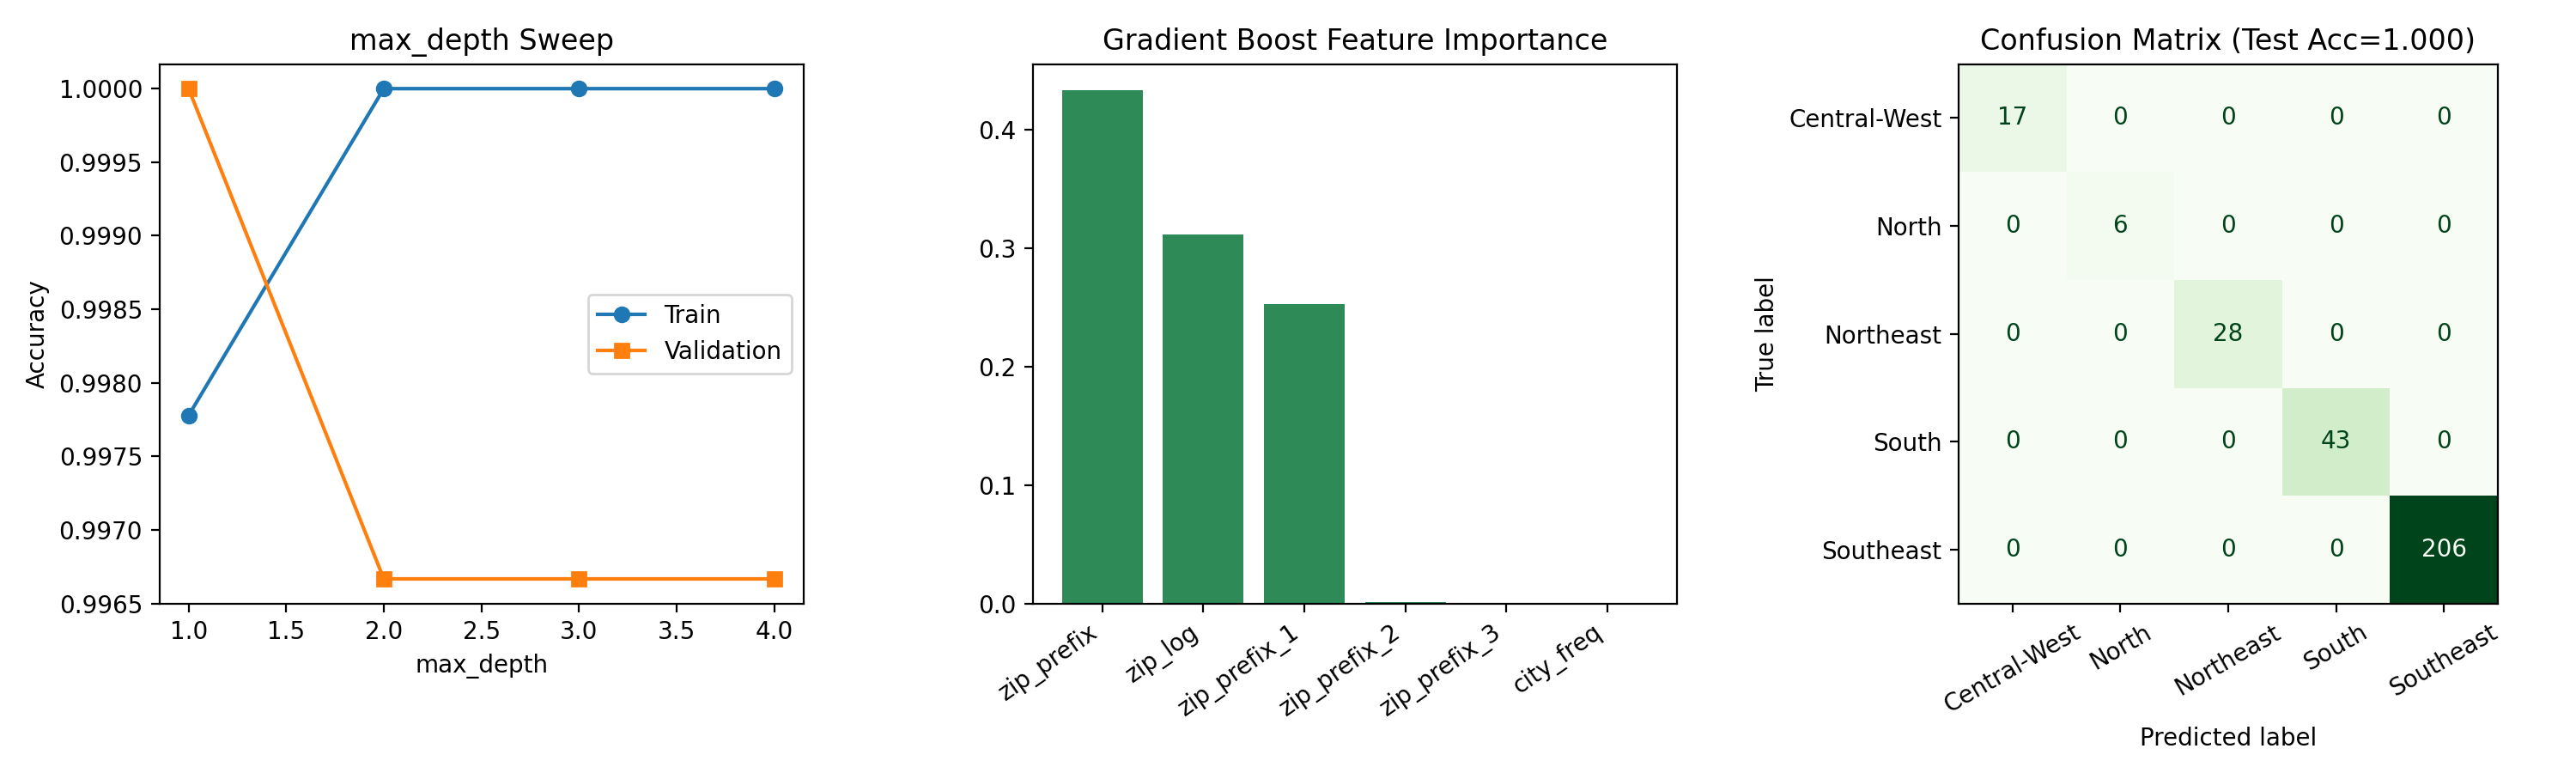

In [3]:
# Display Figure 2
from IPython.display import Image, display
display(Image(filename='fig_wk9_depth_confusion.png'))

**Conclusion (Depth Week):** Gradient boosting reached 100% test accuracy with n_estimators=200, learning_rate=0.05, max_depth=1. See Milestone 2 summary document for the full depth-level discussion.